## 4b. Supervised Learning — Predicting Customer Churn

### Prediction objective

The supervised-learning task is to estimate the probability that a customer will churn (`Churn = Yes`) from the customer information available in the Telco dataset.

- **Target:** `Churn`
- **Excluded identifier:** `customerID`
- **Prediction output:** the estimated probability of churn, not only a hard Yes/No label
- **Important leakage safeguard:** both `Churn` and any duplicate target column such as `Churn_Numeric` are removed from the predictors.

This section should be inserted **after the completed data cleaning and EDA section** and before the final cross-method synthesis. It deliberately does not use cluster labels as predictors. A cluster label may be added only if clustering is fitted inside each training fold; otherwise, learning clusters from the full dataset would leak information from the test set.

### 4b.1 Data preparation and stratified train/test split

We first create the predictor matrix `X` and binary target `y`. The split is stratified so that the churn proportion remains approximately equal in the training and test sets. This matters because churn is the minority class.

The test set is held aside and is **not** used for model selection or hyperparameter tuning. A fixed `random_state` makes the results reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20


def load_telco_dataframe() -> tuple[pd.DataFrame, str]:
    """Use the notebook's existing df; otherwise load the standard CSV."""
    existing_df = globals().get("df")
    required_columns = {"customerID", "Churn", "TotalCharges"}
    if isinstance(existing_df, pd.DataFrame) and required_columns.issubset(existing_df.columns):
        return existing_df.copy(), "existing notebook dataframe `df`"

    candidate_paths = [
        Path("Telco-Customer-Churn.csv"),
        Path("data/Telco-Customer-Churn.csv"),
        Path("/mnt/data/Telco-Customer-Churn.csv"),
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            return pd.read_csv(candidate), str(candidate)

    try:
        import kagglehub
        dataset_dir = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
        return pd.read_csv(dataset_dir / "WA_Fn-UseC_-Telco-Customer-Churn.csv"), "KaggleHub download"
    except (ImportError, FileNotFoundError) as exc:
        raise FileNotFoundError(
            "Run the earlier data-loading cells or place Telco-Customer-Churn.csv "
            "in the project root or data/ directory."
        ) from exc


model_df, data_source = load_telco_dataframe()

# Match the current project's cleaning step and make TotalCharges numeric.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
rows_before = len(model_df)
model_df = model_df.dropna(subset=["TotalCharges"]).copy()
rows_removed = rows_before - len(model_df)

y = model_df["Churn"].map({"No": 0, "Yes": 1})
if y.isna().any():
    raise ValueError("Unexpected values found in the Churn target.")

# Exclude identifiers, every target copy, duplicate causal encodings, and any
# cluster label learned outside the supervised cross-validation pipeline.
columns_to_exclude = [
    "customerID",
    "Churn",
    "Churn_Numeric",
    "Contract_numeric",
    "TechSupport_numeric",
    "InternetService_numeric",
    "Cluster",
]
X = model_df.drop(columns=columns_to_exclude, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_test)],
        "Churn count": [int(y_train.sum()), int(y_test.sum())],
        "Churn rate": [y_train.mean(), y_test.mean()],
    },
    index=["Training set", "Test set"],
)

print(f"Data source: {data_source}")
print(f"Rows removed because TotalCharges was blank: {rows_removed}")
print(f"Predictor columns: {X.shape[1]}")
display(split_summary.round({"Churn rate": 3}))

Data source: Telco-Customer-Churn.csv
Rows removed because TotalCharges was blank: 11
Predictor columns: 19


,Rows,Churn count,Churn rate
Training set,5625,1495,0.266
Test set,1407,374,0.266


**Interpretation.** In this run, the training set contains 5,625 customers and the test set contains 1,407 customers. The churn rate is about 26.6% in both sets, confirming that stratification preserved the class distribution. The 11 rows with blank `TotalCharges` are removed to remain consistent with the current project notebook; imputers are nevertheless retained in the pipeline as a safeguard for future data.

### 4b.2 Leakage-safe preprocessing

The feature types are handled separately:

- Numeric variables are median-imputed and standardized. Scaling is important for Logistic Regression because its coefficients are sensitive to feature scale.
- Categorical variables are mode-imputed and one-hot encoded.
- `handle_unknown="ignore"` allows the model to process a category that was absent from a training fold.
- All transformations are inside a `ColumnTransformer` and a model `Pipeline`. Therefore, preprocessing is learned only from the relevant training fold during cross-validation, which prevents data leakage.

`SeniorCitizen` is treated as categorical because its values 0 and 1 represent groups rather than a continuous quantity.

In [2]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [column for column in X.columns if column not in numerical_features]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

feature_type_summary = pd.DataFrame(
    {
        "Feature type": ["Numerical", "Categorical"],
        "Count": [len(numerical_features), len(categorical_features)],
        "Features": [
            ", ".join(numerical_features),
            ", ".join(categorical_features),
        ],
    }
)
display(feature_type_summary)

,Feature type,Count,Features
0,Numerical,3,"tenure, MonthlyCharges, TotalCharges"
1,Categorical,16,"gender, SeniorCitizen, Partner, Dependents, Ph..."


**Interpretation.** Three continuous variables are standardized, while the remaining variables—including `SeniorCitizen`—are encoded as categorical features. Because these steps are part of each model pipeline, the test-set distribution does not influence imputation, scaling, or category construction.

### 4b.3 Models and validation strategy

Three models are compared:

1. **DummyClassifier:** a no-skill baseline that always uses the training-set class prior. A real model must outperform it.
2. **Logistic Regression:** an interpretable linear probability-ranking model. Its coefficients help identify positive and negative predictive associations.
3. **Random Forest:** a nonlinear ensemble that can capture interactions and threshold effects without assuming a linear relationship.

Model selection uses five-fold **Stratified K-Fold cross-validation only on the training data**. Hyperparameters are selected by ROC-AUC. The untouched test set is used once for the final comparison.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DummyClassifier(strategy="prior")),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

logistic_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

random_forest_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [8, None],
    "model__min_samples_leaf": [5],
    "model__class_weight": [None, "balanced_subsample"],
}

dummy_pipeline.fit(X_train, y_train)

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    refit=True,
)
logistic_search.fit(X_train, y_train)

random_forest_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    refit=True,
)
random_forest_search.fit(X_train, y_train)

best_models = {
    "Dummy baseline": dummy_pipeline,
    "Logistic Regression": logistic_search.best_estimator_,
    "Random Forest": random_forest_search.best_estimator_,
}

validation_summary = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Best mean CV ROC-AUC": [
            logistic_search.best_score_,
            random_forest_search.best_score_,
        ],
        "Best parameters": [
            logistic_search.best_params_,
            random_forest_search.best_params_,
        ],
    }
)
display(validation_summary.assign(**{"Best mean CV ROC-AUC": validation_summary["Best mean CV ROC-AUC"].round(3)}))

,Model,Best mean CV ROC-AUC,Best parameters
0,Logistic Regression,0.846,"{'model__C': 10.0, 'model__class_weight': None}"
1,Random Forest,0.848,"{'model__class_weight': 'balanced_subsample', ..."


**Interpretation.** The best Logistic Regression configuration uses `C=10` without class weighting and obtains a mean cross-validated ROC-AUC of about 0.846. The best Random Forest uses 200 trees, depth 8, a minimum leaf size of 5, and balanced-subsample class weights, with a mean cross-validated ROC-AUC of about 0.848. These close validation scores make the final test-set comparison important.

### 4b.4 Final evaluation on the untouched test set

The following metrics answer different questions:

- **ROC-AUC:** overall ranking quality across thresholds.
- **PR-AUC (Average Precision):** ranking quality with emphasis on the minority churn class.
- **Precision:** among customers predicted to churn, how many actually churn.
- **Recall:** among actual churners, how many are detected.
- **F1-score:** harmonic balance of precision and recall.
- **Accuracy:** overall fraction classified correctly, reported but not used alone because the classes are imbalanced.

In [4]:
def evaluate_binary_classifier(model, X_eval, y_eval):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = model.predict(X_eval)
    metrics = {
        "ROC-AUC": roc_auc_score(y_eval, probabilities),
        "PR-AUC": average_precision_score(y_eval, probabilities),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "Recall": recall_score(y_eval, predictions, zero_division=0),
        "F1-score": f1_score(y_eval, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_eval, predictions),
    }
    return metrics, predictions, probabilities

metric_rows = []
test_predictions = {}
test_probabilities = {}
test_confusion_matrices = {}

for model_name, fitted_model in best_models.items():
    metrics, predictions, probabilities = evaluate_binary_classifier(
        fitted_model, X_test, y_test
    )
    metric_rows.append({"Model": model_name, **metrics})
    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities
    test_confusion_matrices[model_name] = confusion_matrix(y_test, predictions)

results_table = pd.DataFrame(metric_rows).set_index("Model")
display(results_table.round(3))

,ROC-AUC,PR-AUC,Precision,Recall,F1-score,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.835,0.620,0.641,0.572,0.605,0.801
Random Forest,0.838,0.645,0.518,0.789,0.626,0.749


**Interpretation.** The Dummy baseline reaches 73.4% accuracy simply by predicting no churn for everyone, but its recall and F1-score are zero. This demonstrates why accuracy alone is misleading. Logistic Regression reaches ROC-AUC 0.835 and offers higher precision (0.641), while Random Forest has the highest ROC-AUC (0.838), PR-AUC (0.645), recall (0.789), and F1-score (0.626).

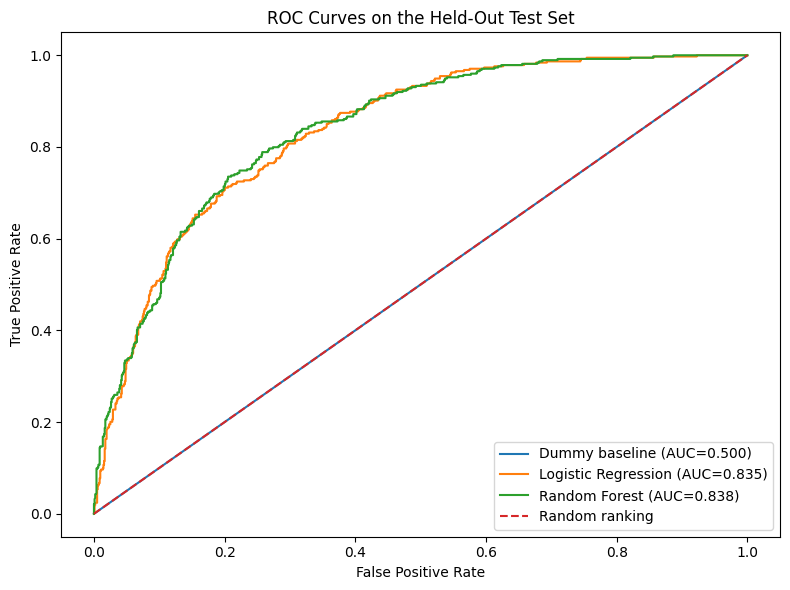

In [5]:
plt.figure(figsize=(8, 6))
for model_name, probabilities in test_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    model_auc = results_table.loc[model_name, "ROC-AUC"]
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC={model_auc:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on the Held-Out Test Set")
plt.legend()
plt.tight_layout()
plt.show()

**ROC interpretation.** Both trained models rank churners substantially better than the Dummy baseline. Their ROC curves are close, with Random Forest slightly ahead on the held-out test set.

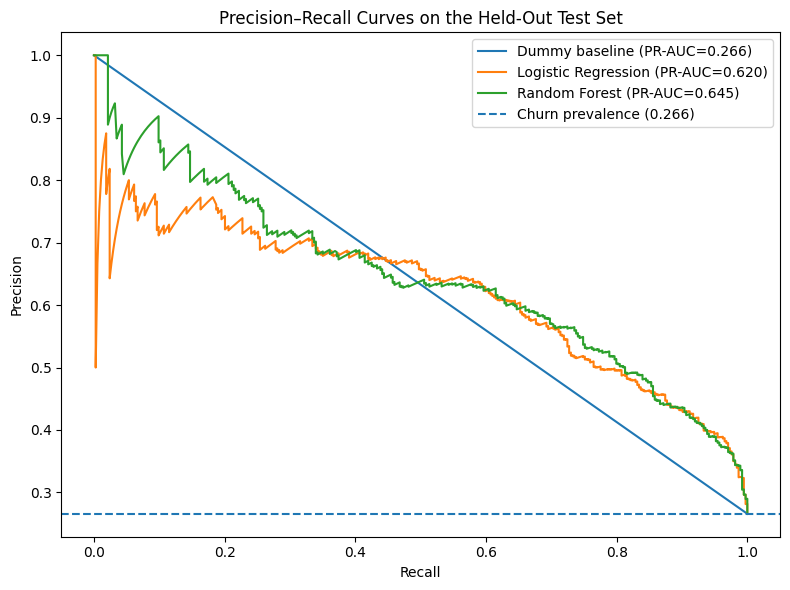

In [6]:
plt.figure(figsize=(8, 6))
for model_name, probabilities in test_probabilities.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test, probabilities)
    model_ap = results_table.loc[model_name, "PR-AUC"]
    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (PR-AUC={model_ap:.3f})",
    )

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Churn prevalence ({y_test.mean():.3f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves on the Held-Out Test Set")
plt.legend()
plt.tight_layout()
plt.show()

**Precision–recall interpretation.** Random Forest provides the strongest precision–recall ranking in this run. PR-AUC is especially informative here because only about 26.6% of customers churn.

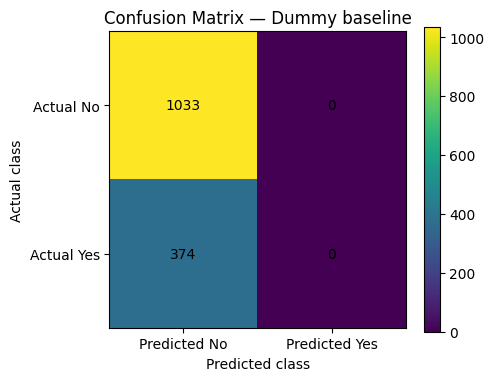

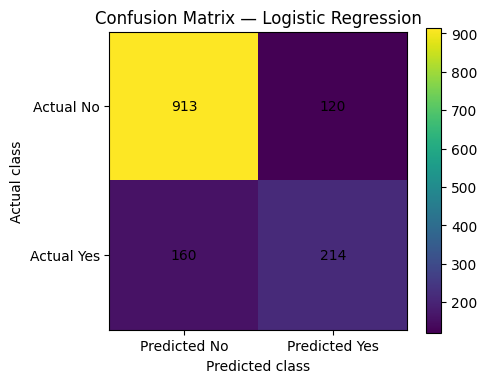

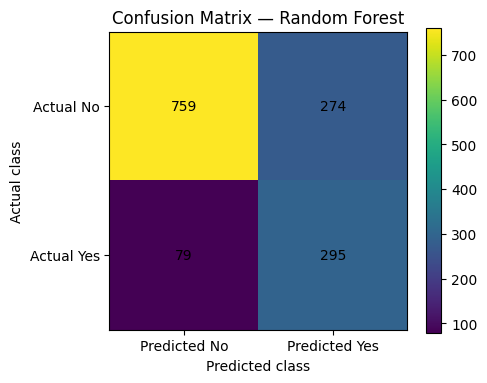

,True negatives,False positives,False negatives,True positives
Model,,,,
Dummy baseline,1033,0,374,0
Logistic Regression,913,120,160,214
Random Forest,759,274,79,295


In [7]:
for model_name, matrix in test_confusion_matrices.items():
    plt.figure(figsize=(5, 4))
    image = plt.imshow(matrix)
    plt.colorbar(image)
    plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
    plt.yticks([0, 1], ["Actual No", "Actual Yes"])
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.title(f"Confusion Matrix — {model_name}")

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(column, row, str(matrix[row, column]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

confusion_table = pd.DataFrame(
    [
        {
            "Model": model_name,
            "True negatives": matrix[0, 0],
            "False positives": matrix[0, 1],
            "False negatives": matrix[1, 0],
            "True positives": matrix[1, 1],
        }
        for model_name, matrix in test_confusion_matrices.items()
    ]
).set_index("Model")
display(confusion_table)

**Confusion-matrix interpretation.** Logistic Regression finds 214 of 374 churners and produces 120 false alarms. Random Forest finds 295 churners and misses only 79, but produces 274 false alarms. Therefore, Random Forest is preferable when missing a churner is costly; Logistic Regression is preferable when retention actions are expensive and false alarms must be limited.

### 4b.5 Logistic Regression coefficients

The coefficients are shown on the log-odds scale. A positive coefficient is associated with a higher predicted churn probability, while a negative coefficient is associated with a lower predicted churn probability, holding the other encoded variables constant.

Because numeric variables are standardized, their coefficients correspond to approximately one standard-deviation changes. Categorical coefficients are relative to the category omitted by `drop="first"`.

,Feature,Coefficient,Absolute coefficient
0,InternetService_Fiber optic,2.073,2.073
1,MonthlyCharges,-1.599,1.599
2,Contract_Two year,-1.410,1.410
3,tenure,-1.404,1.404
4,MultipleLines_No phone service,-1.186,1.186
5,PhoneService_Yes,-0.783,0.783
6,Contract_One year,-0.762,0.762
7,StreamingTV_Yes,0.754,0.754
8,StreamingMovies_Yes,0.727,0.727
9,TotalCharges,0.699,0.699


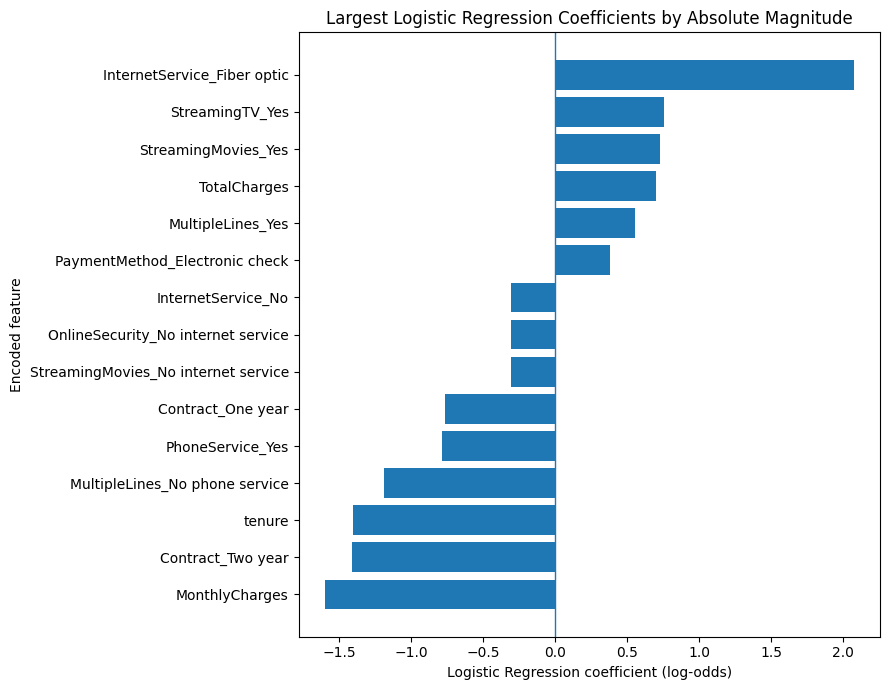

In [8]:
best_logistic = best_models["Logistic Regression"]
logistic_feature_names = best_logistic.named_steps["preprocessor"].get_feature_names_out()
logistic_coefficients = best_logistic.named_steps["model"].coef_[0]

coefficient_table = (
    pd.DataFrame(
        {
            "Feature": logistic_feature_names,
            "Coefficient": logistic_coefficients,
            "Absolute coefficient": np.abs(logistic_coefficients),
        }
    )
    .sort_values("Absolute coefficient", ascending=False)
    .reset_index(drop=True)
)

display(coefficient_table.head(15).round({"Coefficient": 3, "Absolute coefficient": 3}))

top_coefficients = coefficient_table.head(15).sort_values("Coefficient")
plt.figure(figsize=(9, 7))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression coefficient (log-odds)")
plt.ylabel("Encoded feature")
plt.title("Largest Logistic Regression Coefficients by Absolute Magnitude")
plt.tight_layout()
plt.show()

**Coefficient interpretation.** `InternetService_Fiber optic`, streaming-service indicators, and electronic-check payment have strong positive predictive associations with churn. Longer `tenure` and one- or two-year contracts have strong negative associations. Some conditional signs can appear counterintuitive—for example, the coefficient of `MonthlyCharges` is negative after controlling for fiber service, add-ons, tenure, and total charges. Coefficients should therefore be interpreted jointly and as predictive associations, not isolated causal effects.

### 4b.6 Random Forest feature importance

The forest's impurity-based importance measures how much each encoded variable contributes to reducing node impurity across the trees. It gives no direction of effect and can favor continuous or high-cardinality variables, so it should be treated as descriptive model interpretation rather than a causal claim.

,Feature,Importance
0,tenure,0.190
1,TotalCharges,0.125
2,Contract_Two year,0.125
3,InternetService_Fiber optic,0.077
4,MonthlyCharges,0.074
5,PaymentMethod_Electronic check,0.067
6,Contract_One year,0.047
7,OnlineSecurity_Yes,0.040
8,TechSupport_No internet service,0.024
9,DeviceProtection_No internet service,0.023


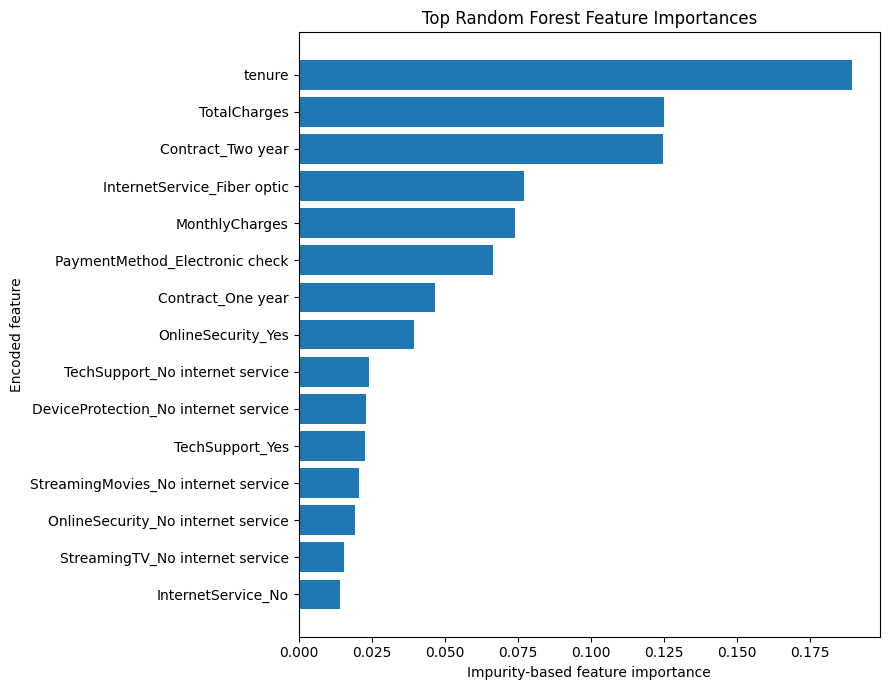

In [9]:
best_forest = best_models["Random Forest"]
forest_feature_names = best_forest.named_steps["preprocessor"].get_feature_names_out()
forest_importances = best_forest.named_steps["model"].feature_importances_

importance_table = (
    pd.DataFrame(
        {
            "Feature": forest_feature_names,
            "Importance": forest_importances,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_table.head(15).round({"Importance": 3}))

top_importances = importance_table.head(15).sort_values("Importance")
plt.figure(figsize=(9, 7))
plt.barh(top_importances["Feature"], top_importances["Importance"])
plt.xlabel("Impurity-based feature importance")
plt.ylabel("Encoded feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

**Feature-importance interpretation.** `tenure`, `TotalCharges`, contract duration, fiber-optic internet, `MonthlyCharges`, and electronic-check payment are among the strongest Random Forest predictors. Importance does not show whether a variable raises or lowers churn, and it does not establish that intervening on that variable would change churn.

### 4b.7 Operational interpretation and model choice

A **false negative** is a customer who actually churns but is predicted not to churn. The company loses the opportunity to intervene. A **false positive** is a non-churner predicted to churn. The company may spend money on an unnecessary retention offer.

At the default 0.50 threshold:

- **Random Forest is the better choice when high recall is the priority.** It detects about 78.9% of churners and has the highest PR-AUC and F1-score, but it creates more false positives.
- **Logistic Regression offers a better precision–recall trade-off when interventions are costly.** Its precision is about 64.1%, and it produces far fewer false positives.
- The final production threshold should be chosen from business costs rather than automatically fixed at 0.50. For example, a lower threshold raises recall but usually lowers precision.

### 4b.8 Connection to causal inference

Predictive importance is **not** the same as causal effect. A model may use `Contract` very effectively because contract type is associated with tenure, customer preferences, service bundles, affordability, or unobserved customer characteristics.

Therefore, finding that long-term contracts predict lower churn does **not** prove that persuading a customer to change contracts would reduce churn by the same amount. A causal conclusion requires an explicit causal estimand, assumptions about confounding, a defensible causal graph, and an appropriate identification/estimation strategy. The supervised model answers **“Who is likely to churn?”**; the causal analysis should answer a separate question such as **“What would happen to churn if a specific intervention changed?”**

### 4b.9 Reproducibility and rubric checklist

- [x] Target is `Churn`; `customerID` and all target duplicates are excluded.
- [x] Stratified 80/20 train/test split with fixed `random_state=42`.
- [x] Test set is not used for model selection.
- [x] Numeric and categorical columns are processed with `ColumnTransformer`.
- [x] Imputation, scaling, and one-hot encoding are inside model pipelines.
- [x] Dummy baseline, interpretable Logistic Regression, and nonlinear Random Forest are compared.
- [x] Five-fold Stratified K-Fold cross-validation is used.
- [x] Hyperparameter tuning is performed only on training data.
- [x] ROC-AUC, PR-AUC, precision, recall, F1, accuracy, confusion matrices, ROC curves, and precision–recall curves are reported.
- [x] Logistic coefficients and Random Forest feature importance are interpreted.
- [x] Accuracy limitations, false positives, and false negatives are discussed.
- [x] Predictive associations are explicitly separated from causal effects.
- [x] All reported values come from the executed held-out evaluation.